In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, multivariate_normal, wasserstein_distance


def simulate_ma3_path(n, coefficients=(1.0, 0.6, 0.4, 0.2), rng=None):
    """Simulate one MA(3) path of exact length n with standard normal innovations."""
    rng = np.random.default_rng() if rng is None else rng
    coeffs = np.asarray(coefficients, dtype=float)
    q = len(coeffs) - 1
    innovations = rng.standard_normal(n + q)

    path = np.zeros(n, dtype=float)
    for j, coefficient in enumerate(coeffs):
        path += coefficient * innovations[q - j:q - j + n]
    return path


def generate_ma3_realizations(m, n, coefficients=(1.0, 0.6, 0.4, 0.2), rng=None):
    """Generate m independent realizations and return an array of shape (m, n)."""
    rng = np.random.default_rng() if rng is None else rng
    return np.vstack([simulate_ma3_path(n, coefficients=coefficients, rng=rng) for _ in range(m)])


def marginal_variance():
    """The exact marginal variance tau^2 of the MA(3) model."""
    return 1.56


def autocovariances():
    """Return the exact nonzero autocovariances gamma(0), ..., gamma(3)."""
    return {0: 1.56, 1: 0.92, 2: 0.52, 3: 0.20}


def autocovariance(k):
    """Return gamma(k), which is zero for |k| > 3."""
    return autocovariances().get(abs(int(k)), 0.0)


def correlation(k):
    """Return the exact correlation r_k = gamma(k) / gamma(0)."""
    return autocovariance(k) / marginal_variance()


def standard_bivariate_normal_cdf(u, v, rho):
    """Evaluate Phi_2(u, v; rho), handling rho = 1 exactly."""
    u_array, v_array = np.broadcast_arrays(np.asarray(u, dtype=float), np.asarray(v, dtype=float))

    if np.isclose(rho, 1.0):
        result = norm.cdf(np.minimum(u_array, v_array))
    else:
        points = np.column_stack([u_array.ravel(), v_array.ravel()])
        covariance = np.array([[1.0, rho], [rho, 1.0]], dtype=float)
        result = multivariate_normal(mean=np.zeros(2), cov=covariance).cdf(points).reshape(u_array.shape)

    if result.ndim == 0:
        return float(result)
    return result


def theoretical_covariance_kernel(x, y):
    """
    Compute
        Gamma(x, y) = sum_{k=-3}^3 Cov(1{X_0 <= x}, 1{X_k <= y})
    for the MA(3) Gaussian sequence using the exact covariance structure.
    """
    tau = np.sqrt(marginal_variance())
    u = x / tau
    v = y / tau
    marginal_term = norm.cdf(u) * norm.cdf(v)

    kernel_value = 0.0
    for lag, multiplicity in ((0, 1), (1, 2), (2, 2), (3, 2)):
        joint_cdf = standard_bivariate_normal_cdf(u, v, correlation(lag))
        kernel_value += multiplicity * (joint_cdf - marginal_term)
    return float(kernel_value)


def build_covariance_matrix(grid):
    """Build Sigma_{ij} = Gamma(x_i, x_j) on a finite grid."""
    grid = np.asarray(grid, dtype=float)
    tau = np.sqrt(marginal_variance())
    scaled_grid = grid / tau
    u_matrix, v_matrix = np.meshgrid(scaled_grid, scaled_grid, indexing="ij")
    marginal_term = norm.cdf(u_matrix) * norm.cdf(v_matrix)

    sigma = np.zeros((grid.size, grid.size), dtype=float)
    for lag, multiplicity in ((0, 1), (1, 2), (2, 2), (3, 2)):
        joint_cdf = standard_bivariate_normal_cdf(u_matrix, v_matrix, correlation(lag))
        sigma += multiplicity * (joint_cdf - marginal_term)

    return 0.5 * (sigma + sigma.T)


def stabilize_covariance_matrix(covariance_matrix, target_min_eigenvalue=1e-10):
    """Symmetrize and add the smallest diagonal jitter needed for numerical stability."""
    stabilized = 0.5 * (covariance_matrix + covariance_matrix.T)
    min_eigenvalue = np.linalg.eigvalsh(stabilized).min()
    jitter = max(0.0, target_min_eigenvalue - min_eigenvalue)
    if jitter > 0.0:
        stabilized = stabilized + jitter * np.eye(stabilized.shape[0])
    return stabilized, jitter, min_eigenvalue


def simulate_gaussian_process_draw(covariance_matrix, rng=None):
    """Simulate one Gaussian process draw on the grid from N(0, Sigma)."""
    rng = np.random.default_rng() if rng is None else rng
    mean = np.zeros(covariance_matrix.shape[0], dtype=float)
    return rng.multivariate_normal(mean=mean, cov=covariance_matrix)


def gaussian_l1_functional(grid, process_values):
    """Approximate integral |Z(x)| dx by the trapezoidal rule on the grid."""
    return np.trapz(np.abs(process_values), x=grid)


def compute_pairwise_wasserstein_distances(realizations):
    """Compute all pairwise Wasserstein-1 distances W(F_n^(i), F_n^(j)) for i < j."""
    realizations = np.asarray(realizations, dtype=float)
    num_paths = realizations.shape[0]
    num_pairs = num_paths * (num_paths - 1) // 2
    pairwise_distances = np.empty(num_pairs, dtype=float)

    index = 0
    for i in range(num_paths - 1):
        sample_i = realizations[i]
        for j in range(i + 1, num_paths):
            pairwise_distances[index] = wasserstein_distance(sample_i, realizations[j])
            index += 1
    return pairwise_distances


def simulate_gaussian_functionals(covariance_matrix, grid, num_draws, rng=None):
    """Simulate many Gaussian draws and return the corresponding L1 functionals."""
    rng = np.random.default_rng() if rng is None else rng
    mean = np.zeros(covariance_matrix.shape[0], dtype=float)
    draws = rng.multivariate_normal(mean=mean, cov=covariance_matrix, size=num_draws)
    return np.trapz(np.abs(draws), x=grid, axis=1)


In [6]:
# Fixed seed for full reproducibility of both the data and Gaussian approximation.
seed = 20260325
rng = np.random.default_rng(seed)

num_realizations = 100
n = 1000
paths = generate_ma3_realizations(num_realizations, n, rng=rng)

print(f"paths.shape = {paths.shape}")
print(f"Empirical mean over all entries: {paths.mean():.4f}")
print(f"Empirical variance over all entries: {paths.var():.4f}")
print("First five values of the first realization:")
print(np.round(paths[0, :5], 4))
print(f"Theoretical marginal variance tau^2 = {marginal_variance():.2f}")


paths.shape = (100, 1000)
Empirical mean over all entries: -0.0009
Empirical variance over all entries: 1.5497
First five values of the first realization:
[ 0.6331 -0.1206 -0.6871  1.0227  0.9058]
Theoretical marginal variance tau^2 = 1.56


In [3]:
# Part A: empirical pairwise Wasserstein distances.
pairwise_W = compute_pairwise_wasserstein_distances(paths)
scaled_pairwise_W = np.sqrt(n) * pairwise_W

print(f"Number of pairwise distances: {pairwise_W.size}")
print(f"Expected number choose(100, 2): {100 * 99 // 2}")
print(f"Mean of W: {pairwise_W.mean():.6f}")
print(f"Std of W: {pairwise_W.std(ddof=1):.6f}")
print(f"Mean of sqrt(n) * W: {scaled_pairwise_W.mean():.4f}")
print(f"Std of sqrt(n) * W: {scaled_pairwise_W.std(ddof=1):.4f}")
print("Selected quantiles of sqrt(n) * W:")
print(np.round(np.quantile(scaled_pairwise_W, [0.05, 0.25, 0.5, 0.75, 0.95]), 4))

# Part B: Gaussian limiting approximation based on the exact theoretical kernel.
x_grid = np.linspace(-6.0, 6.0, 351)
Sigma = build_covariance_matrix(x_grid)

max_asymmetry = np.max(np.abs(Sigma - Sigma.T))
print(f"Maximum absolute asymmetry in Sigma: {max_asymmetry:.3e}")

Sigma_stable, sigma_jitter, sigma_min_eigenvalue = stabilize_covariance_matrix(Sigma)
print(f"Minimum eigenvalue of raw Sigma: {sigma_min_eigenvalue:.3e}")
print(f"Diagonal jitter added to Sigma: {sigma_jitter:.3e}")

# The pairwise limit is the L1 norm of G_i - G_j, so its covariance is 2 * Sigma.
limit_covariance = 2.0 * Sigma_stable
limit_covariance, limit_jitter, limit_min_eigenvalue = stabilize_covariance_matrix(limit_covariance)
print(f"Minimum eigenvalue of 2*Sigma before stabilization: {limit_min_eigenvalue:.3e}")
print(f"Additional diagonal jitter added to 2*Sigma: {limit_jitter:.3e}")

num_gaussian_draws = 5000
gaussian_limit_samples = simulate_gaussian_functionals(limit_covariance, x_grid, num_gaussian_draws, rng=rng)

print(f"Number of Gaussian limit samples: {gaussian_limit_samples.size}")
print(f"Mean of Gaussian limit samples: {gaussian_limit_samples.mean():.4f}")
print(f"Std of Gaussian limit samples: {gaussian_limit_samples.std(ddof=1):.4f}")
print("Selected quantiles of Gaussian limit samples:")
print(np.round(np.quantile(gaussian_limit_samples, [0.05, 0.25, 0.5, 0.75, 0.95]), 4))

empirical_mean = scaled_pairwise_W.mean()
empirical_std = scaled_pairwise_W.std(ddof=1)
gaussian_mean = gaussian_limit_samples.mean()
gaussian_std = gaussian_limit_samples.std(ddof=1)
print(
    f"Comparison of mean/std: empirical = ({empirical_mean:.4f}, {empirical_std:.4f}), "
    f"Gaussian approximation = ({gaussian_mean:.4f}, {gaussian_std:.4f})"
)


Number of pairwise distances: 4950
Expected number choose(100, 2): 4950
Mean of W: 0.106801
Std of W: 0.052801
Mean of sqrt(n) * W: 3.3774
Std of sqrt(n) * W: 1.6697
Selected quantiles of sqrt(n) * W:
[1.4459 2.1156 2.9496 4.2973 6.7326]
Maximum absolute asymmetry in Sigma: 0.000e+00
Minimum eigenvalue of raw Sigma: 3.658e-08
Diagonal jitter added to Sigma: 0.000e+00
Minimum eigenvalue of 2*Sigma before stabilization: 7.317e-08
Additional diagonal jitter added to 2*Sigma: 0.000e+00
Number of Gaussian limit samples: 5000
Mean of Gaussian limit samples: 3.2566
Std of Gaussian limit samples: 1.5063
Selected quantiles of Gaussian limit samples:
[1.5037 2.1379 2.8839 4.0106 6.2408]
Comparison of mean/std: empirical = (3.3774, 1.6697), Gaussian approximation = (3.2566, 1.5063)


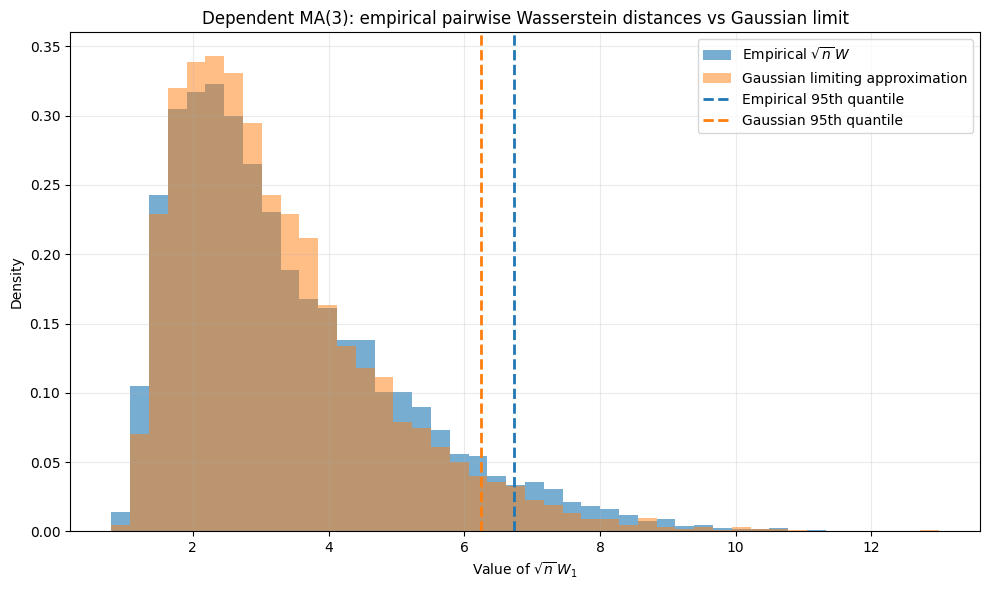

In [7]:
plt.figure(figsize=(10, 6))

combined_samples = np.concatenate([scaled_pairwise_W, gaussian_limit_samples])
bins = np.linspace(combined_samples.min(), combined_samples.max(), 45)

plt.hist(
    scaled_pairwise_W,
    bins=bins,
    density=True,
    alpha=0.60,
    color="C0",
    label=r"Empirical $\sqrt{n}\,W$"
)
plt.hist(
    gaussian_limit_samples,
    bins=bins,
    density=True,
    alpha=0.50,
    color="C1",
    label="Gaussian limiting approximation"
)

plt.axvline(np.quantile(scaled_pairwise_W, 0.95), color="C0", linestyle="--", linewidth=2, label="Empirical 95th quantile")
plt.axvline(np.quantile(gaussian_limit_samples, 0.95), color="C1", linestyle="--", linewidth=2, label="Gaussian 95th quantile")

plt.title("Dependent MA(3): empirical pairwise Wasserstein distances vs Gaussian limit")
plt.xlabel(r"Value of $\sqrt{n}\,W_1$")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()
